# **1. DESCARGA Y DESCOMPRESIÓN DEL DATASET "VisDrone"**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CARGA DEL DATASET VISDRONE DESDE GOOGLE DRIVE
# Estrategia: copiar primero a disco local, luego descomprimir
# Verifica cada partición de forma independiente
# ============================================================
from google.colab import drive
import zipfile
import shutil
import os

drive.mount('/content/drive')

ruta_train_zip = "/content/drive/MyDrive/datasets-perc-comp/VisDrone2019-DET-train.zip"
ruta_val_zip   = "/content/drive/MyDrive/datasets-perc-comp/VisDrone2019-DET-val.zip"

# Verificamos cada carpeta por separado para manejar extracciones parciales
# como la que ocurrió en la sesión anterior
if not os.path.exists("VisDrone2019-DET-train"):
    print("Copiando trainset desde Drive al disco local (1.44 GB)...")
    shutil.copy(ruta_train_zip, "/content/VisDrone2019-DET-train.zip")
    print("Descomprimiendo trainset...")
    with zipfile.ZipFile("/content/VisDrone2019-DET-train.zip", 'r') as z:
        z.extractall(".")
    os.remove("/content/VisDrone2019-DET-train.zip")
    print("✓ Trainset listo.")
else:
    print("✓ Trainset ya existe. Omitiendo.")

if not os.path.exists("VisDrone2019-DET-val"):
    print("\nCopiando valset desde Drive al disco local (70 MB)...")
    shutil.copy(ruta_val_zip, "/content/VisDrone2019-DET-val.zip")
    print("Descomprimiendo valset...")
    with zipfile.ZipFile("/content/VisDrone2019-DET-val.zip", 'r') as z:
        z.extractall(".")
    os.remove("/content/VisDrone2019-DET-val.zip")
    print("✓ Valset listo.")
else:
    print("✓ Valset ya existe. Omitiendo.")

# Verificación final de ambas particiones
imagenes_train = os.listdir("VisDrone2019-DET-train/images")
imagenes_val   = os.listdir("VisDrone2019-DET-val/images")
print(f"\n  Imágenes en trainset: {len(imagenes_train)}")
print(f"  Imágenes en valset:   {len(imagenes_val)}")
print(f"  Primera imagen:       {sorted(imagenes_train)[0]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiando trainset desde Drive al disco local (1.44 GB)...
Descomprimiendo trainset...
✓ Trainset listo.

Copiando valset desde Drive al disco local (70 MB)...
Descomprimiendo valset...
✓ Valset listo.

  Imágenes en trainset: 6471
  Imágenes en valset:   548
  Primera imagen:       0000002_00005_d_0000014.jpg


# **2. DESCARGA DE UrbanSound8K E INSTALACIÓN DE LIBROSA**

In [ ]:
# ============================================================
# CARGA DE URBANSOUND8K DESDE GOOGLE DRIVE + INSTALACIÓN LIBROSA
# ============================================================
import os

ruta_audio_tar = "/content/drive/MyDrive/datasets-perc-comp/UrbanSound8K.tar.gz"

if not os.path.exists("UrbanSound8K"):
    print("Extrayendo UrbanSound8K (~6 GB)...")
    print("Esto puede tardar varios minutos según el rendimiento de Drive.\n")

    # tar -xzf extrae archivos .tar.gz directamente, igual que unzip
    !tar -xzf "{ruta_audio_tar}"

    print("✓ Extracción completada.")
else:
    print("✓ UrbanSound8K ya existe en el entorno. Omitiendo extracción.")


# Verificación de la estructura del dataset
import pandas as pd

metadata       = pd.read_csv("UrbanSound8K/metadata/UrbanSound8K.csv")
archivos_fold1 = os.listdir("UrbanSound8K/audio/fold1")

print(f"\n✓ Dataset UrbanSound8K cargado correctamente.")
print(f"  Total de clips en el CSV:  {len(metadata)}")
print(f"  Clases disponibles:        {metadata['class'].nunique()}")
print(f"  Clases: {list(metadata['class'].unique())}")
print(f"  Archivos en fold1:         {len(archivos_fold1)}")
print(f"  Primer archivo en fold1:   {sorted(archivos_fold1)[0]}")


# Instalación de librosa para el procesamiento de audio
!pip install librosa --quiet

import librosa
print(f"\n✓ librosa instalada. Versión: {librosa.__version__}")

Extrayendo UrbanSound8K (~6 GB)...
Esto puede tardar varios minutos según el rendimiento de Drive.

✓ Extracción completada.

✓ Dataset UrbanSound8K cargado correctamente.
  Total de clips en el CSV:  8732
  Clases disponibles:        10
  Clases: ['dog_bark', 'children_playing', 'car_horn', 'air_conditioner', 'street_music', 'gun_shot', 'siren', 'engine_idling', 'jackhammer', 'drilling']
  Archivos en fold1:         874
  Primer archivo en fold1:   .DS_Store

✓ librosa instalada. Versión: 0.11.0


# **3. PIPELINE COMPLETO DE VIDEO CON VERIFICACIÓN**


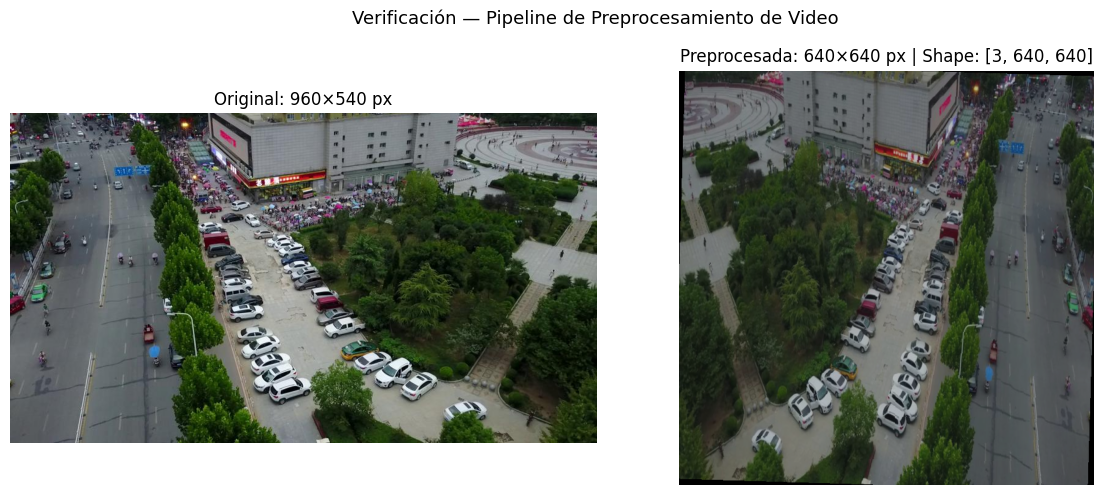

✓ Pipeline de video funcionando. Archivo usado: 0000002_00005_d_0000014.jpg
  Shape del tensor de salida: torch.Size([3, 640, 640])


In [ ]:
# ============================================================
# PIPELINE DE PREPROCESAMIENTO DE VIDEO
# Dataset: VisDrone-DET | Capturas propias (cámara/dron)
# ============================================================

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# ── FUNCIÓN 1: Extracción de frames desde video ──────────────
def extraer_frames(ruta_video, carpeta_salida, fps_muestra=1):
    """
    Extrae frames de un video a una tasa de muestreo definida.
    Por defecto extrae 1 frame por segundo para evitar redundancia.
    Funciona con videos de cámara fija y de dron.
    """
    cap = cv2.VideoCapture(ruta_video)
    fps_original = cap.get(cv2.CAP_PROP_FPS)
    intervalo    = int(fps_original / fps_muestra)

    os.makedirs(carpeta_salida, exist_ok=True)
    frame_idx = 0
    guardados = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % intervalo == 0:
            nombre = os.path.join(carpeta_salida, f"frame_{guardados:05d}.jpg")
            cv2.imwrite(nombre, frame)
            guardados += 1
        frame_idx += 1

    cap.release()
    print(f"Frames extraídos: {guardados} de {frame_idx} totales")


# ── FUNCIÓN 2: Transformaciones para ENTRENAMIENTO ───────────
transform_entrenamiento = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── FUNCIÓN 3: Transformaciones para VALIDACIÓN y PRUEBA ─────
transform_evaluacion = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# ── VERIFICACIÓN DEL PIPELINE DE VIDEO ───────────────────────
# Tomamos la primera imagen del trainset como prueba
# La Celda 0 ya descargó y descomprimió el dataset en esta ruta
primer_imagen = sorted(os.listdir("VisDrone2019-DET-train/images"))[0]
ruta_prueba_video = f"VisDrone2019-DET-train/images/{primer_imagen}"

imagen_original  = Image.open(ruta_prueba_video).convert("RGB")
tensor_procesado = transform_entrenamiento(imagen_original)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(imagen_original)
ejes[0].set_title(f"Original: {imagen_original.size[0]}×{imagen_original.size[1]} px")
ejes[0].axis('off')

imagen_para_mostrar = tensor_procesado.permute(1, 2, 0).numpy()
imagen_para_mostrar = imagen_para_mostrar * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
imagen_para_mostrar = imagen_para_mostrar.clip(0, 1)

ejes[1].imshow(imagen_para_mostrar)
ejes[1].set_title(f"Preprocesada: 640×640 px | Shape: {list(tensor_procesado.shape)}")
ejes[1].axis('off')

plt.suptitle("Verificación — Pipeline de Preprocesamiento de Video", fontsize=13)
plt.tight_layout()
plt.show()
print(f"✓ Pipeline de video funcionando. Archivo usado: {primer_imagen}")
print(f"  Shape del tensor de salida: {tensor_procesado.shape}")

# **4. PIPELINE COMPLETO DE AUDIO**

In [ ]:
# ============================================================
# PIPELINE DE PREPROCESAMIENTO DE AUDIO
# Dataset: UrbanSound8K | Grabaciones propias en Trujillo
# ============================================================

import librosa
import librosa.display
import numpy as np

# Parámetros globales del pipeline de audio.
SR          = 22050   # Tasa de muestreo estándar en Hz
DURACION    = 4.0     # Duración fija en segundos para todos los clips
N_MELS      = 128     # Número de bandas de frecuencia Mel
HOP_LENGTH  = 512     # Tamaño del paso entre ventanas STFT
N_FFT       = 2048    # Tamaño de la ventana para la transformada de Fourier


# ── FUNCIÓN 1: Carga y estandarización de duración ───────────
def cargar_y_estandarizar(ruta_audio):
    """
    Carga un archivo de audio, lo re-muestrea a 22050 Hz
    y lo normaliza a exactamente 4 segundos de duración.
    Funciona con archivos del dataset y con grabaciones propias,
    independientemente de su tasa de muestreo original.
    """
    # librosa convierte automáticamente a mono y re-muestrea al SR indicado.
    # Esto garantiza consistencia aunque el archivo venga a 44100 Hz (grabación propia)
    # o a una tasa variable como los archivos de UrbanSound8K.
    audio, _ = librosa.load(ruta_audio, sr=SR, mono=True)

    longitud_objetivo = int(SR * DURACION)  # = 88200 muestras para 4 segundos

    if len(audio) > longitud_objetivo:
        audio = audio[:longitud_objetivo]           # Recorte si es más largo
    else:
        # Relleno con ceros al final si el clip es más corto (zero-padding)
        audio = np.pad(audio, (0, longitud_objetivo - len(audio)))

    return audio


# ── FUNCIÓN 2: Conversión a espectrograma Mel ─────────────────
def audio_a_mel_espectrograma(audio):
    """
    Convierte una señal de audio en un espectrograma Mel en escala dB.
    El resultado es una imagen de forma (128, 173): 128 bandas de frecuencia
    Mel en el eje vertical y 173 ventanas de tiempo en el horizontal.
    Esta representación visual permite que una CNN procese audio
    exactamente igual que si fuera una imagen de video.
    """
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )
    # Conversión a decibeles: el oído humano percibe el sonido de forma
    # logarítmica, y esta escala también ayuda al modelo a converger mejor.
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalización al rango [0, 1] para compatibilidad con redes neuronales
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())

    return mel_db  # Shape: (128, 173)


# ── FUNCIÓN 3: Aumento de datos de audio ─────────────────────
def aumentar_audio(audio):
    """
    Aplica una técnica de data augmentation elegida aleatoriamente.
    Solo se usa durante el entrenamiento, nunca en validación ni prueba.
    El objetivo es que el modelo generalice mejor a las condiciones
    variables de grabación que encontraremos en las capturas en Trujillo.
    """
    tecnica = np.random.choice(['stretch', 'pitch', 'ruido', 'ninguna'])

    if tecnica == 'stretch':
        # Time stretching: altera la velocidad sin cambiar el tono.
        # Un rate > 1 acelera el audio, < 1 lo ralentiza.
        # Simula distintas densidades de tráfico en la vía.
        rate  = np.random.uniform(0.85, 1.15)
        audio = librosa.effects.time_stretch(audio, rate=rate)
        # Reajuste de duración tras el stretch para mantener los 4 segundos
        longitud = int(SR * DURACION)
        audio = audio[:longitud] if len(audio) > longitud else np.pad(
            audio, (0, longitud - len(audio))
        )

    elif tecnica == 'pitch':
        # Pitch shifting: sube o baja el tono hasta 2 semitonos.
        # Simula diferentes tipos de motores: motos, combis, camiones.
        n_steps = np.random.uniform(-2, 2)
        audio   = librosa.effects.pitch_shift(audio, sr=SR, n_steps=n_steps)

    elif tecnica == 'ruido':
        # Adición de ruido gaussiano de baja intensidad.
        # Simula condiciones de grabación imperfectas (viento, micrófono).
        # El factor 0.005 mantiene el ruido sutil y no distorsionante.
        ruido = np.random.normal(0, 0.005, len(audio))
        audio = audio + ruido

    # Si tecnica == 'ninguna', el audio se devuelve sin modificaciones
    return audio


# ── FUNCIÓN 4: Pipeline completo para un clip ────────────────
def preprocesar_clip(ruta_audio, augmentar=False):
    """
    Pipeline completo para un solo clip de audio.
    Encadena todas las funciones anteriores en el orden correcto:
    carga y estandariza → (augmenta si es entrenamiento) → espectrograma Mel.
    El parámetro 'augmentar=True' solo debe usarse en el set de entrenamiento.
    """
    audio = cargar_y_estandarizar(ruta_audio)
    if augmentar:
        audio = aumentar_audio(audio)
    espectrograma = audio_a_mel_espectrograma(audio)
    return espectrograma  # Shape: (128, 173) — listo para ingresar a una CNN

print("✓ Funciones del pipeline de audio definidas correctamente.")

✓ Funciones del pipeline de audio definidas correctamente.


# **5. VERIFICACIÓN DEL PIPELINE DE AUDIO**

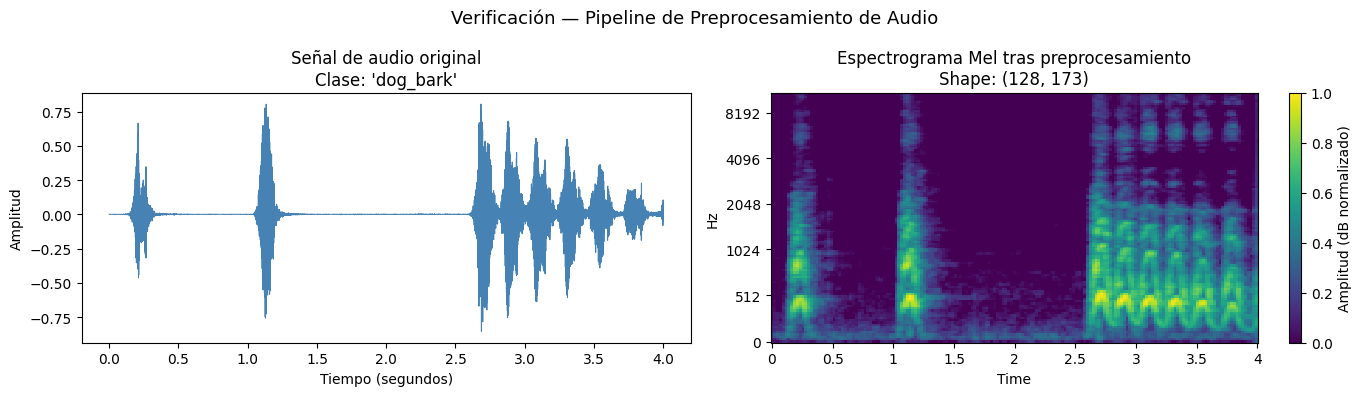

✓ Pipeline de audio funcionando correctamente.
  Archivo usado:             101415-3-0-2.wav
  Clase del clip:            'dog_bark' (classID=3)
  Shape del espectrograma:   (128, 173)
  Esperado:                  (128, 173)


In [ ]:
# ── VERIFICACIÓN DEL PIPELINE DE AUDIO ───────────────────────
# Tomamos dinámicamente el primer archivo de fold1 del dataset,
# de la misma manera que hicimos con VisDrone en la Celda 1.
import matplotlib.pyplot as plt

# Localizar el primer archivo .wav disponible en fold1
archivos_fold1    = sorted(os.listdir("UrbanSound8K/audio/fold1"))
primer_archivo    = archivos_fold1[0]
ruta_prueba_audio = f"UrbanSound8K/audio/fold1/{primer_archivo}"

# Obtener la clase consultando el CSV por nombre de archivo.
# Este método es robusto porque no depende del formato del nombre del archivo,
# sino de los metadatos oficiales del dataset que siempre son consistentes.
info_clip = metadata[metadata['slice_file_name'] == primer_archivo]

if len(info_clip) > 0:
    # Encontrado en el CSV: extraemos classID y nombre de clase directamente
    class_id     = info_clip['classID'].values[0]
    nombre_clase = info_clip['class'].values[0]
else:
    # Si el primer archivo no está en el CSV (por ejemplo, si hay archivos
    # de sistema como .DS_Store al inicio de la lista), buscamos el siguiente
    # archivo válido para no interrumpir la verificación
    for archivo in archivos_fold1:
        info_clip = metadata[metadata['slice_file_name'] == archivo]
        if len(info_clip) > 0:
            primer_archivo    = archivo
            ruta_prueba_audio = f"UrbanSound8K/audio/fold1/{primer_archivo}"
            class_id          = info_clip['classID'].values[0]
            nombre_clase      = info_clip['class'].values[0]
            break

# Aplicar el pipeline completo sin augmentation (modo evaluación)
espectrograma = preprocesar_clip(ruta_prueba_audio, augmentar=False)

# Visualizar el espectrograma Mel resultante como imagen
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: forma de onda original del audio
audio_original, _ = librosa.load(ruta_prueba_audio, sr=SR)
tiempos = np.linspace(0, len(audio_original) / SR, len(audio_original))
ejes[0].plot(tiempos, audio_original, color='steelblue', linewidth=0.7)
ejes[0].set_title(f"Señal de audio original\nClase: '{nombre_clase}'")
ejes[0].set_xlabel("Tiempo (segundos)")
ejes[0].set_ylabel("Amplitud")

# Panel derecho: espectrograma Mel resultante del pipeline
img = librosa.display.specshow(
    espectrograma,
    sr=SR,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel',
    ax=ejes[1],
    cmap='viridis'
)
ejes[1].set_title(f"Espectrograma Mel tras preprocesamiento\nShape: {espectrograma.shape}")
plt.colorbar(img, ax=ejes[1], label='Amplitud (dB normalizado)')

plt.suptitle("Verificación — Pipeline de Preprocesamiento de Audio", fontsize=13)
plt.tight_layout()
plt.show()

print(f"✓ Pipeline de audio funcionando correctamente.")
print(f"  Archivo usado:             {primer_archivo}")
print(f"  Clase del clip:            '{nombre_clase}' (classID={class_id})")
print(f"  Shape del espectrograma:   {espectrograma.shape}")
print(f"  Esperado:                  (128, 173)")

## **6. Modelo Base (Baseline Clásico)**

In [ ]:
# ============================================================
# 4.1. MODELO BASE — BASELINE CLÁSICO
# Video:  HOG (Histogram of Oriented Gradients) + SVM
# Audio:  MFCC (Mel-Frequency Cepstral Coefficients) + SVM
# ============================================================

import cv2
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from skimage.feature import hog
import librosa
import matplotlib.pyplot as plt
import os

print("✓ Librerías del baseline cargadas correctamente.")

✓ Librerías del baseline cargadas correctamente.


Extrayendo crops del trainset...
  Positivos: 536 | Negativos: 300
Extrayendo crops del valset...
  Positivos: 191 | Negativos: 100

Extrayendo características HOG...
✓ HOG extraído. Shape X_train: (836, 1764)

Entrenando SVM (kernel lineal)...
✓ SVM entrenado.

  RESULTADO BASELINE — HOG + SVM (Video)
  Precisión global: 80.41%

              precision    recall  f1-score   support

       Fondo       0.71      0.73      0.72       100
    Vehículo       0.86      0.84      0.85       191

    accuracy                           0.80       291
   macro avg       0.78      0.79      0.78       291
weighted avg       0.81      0.80      0.80       291



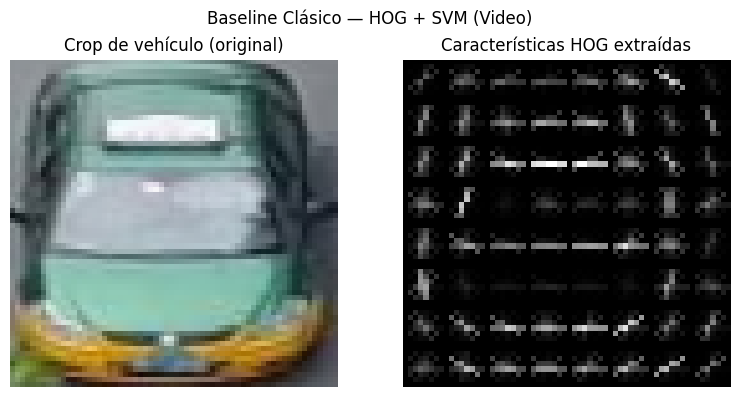

In [ ]:
# ============================================================
# 4.1.A — BASELINE DE VIDEO: HOG + SVM
# ============================================================

TAMANO_CROP      = (64, 64)
MAX_IMGS_TRAIN   = 300
MAX_IMGS_VAL     = 100
CLASES_VEHICULO  = {4, 5, 6, 9, 10}  # car, van, truck, bus, motor

# ── PASO 1: Extraer crops de vehículos (positivos) y fondo (negativos) ──
def extraer_crops(carpeta_dataset, max_imgs):
    positivos, negativos = [], []
    carpeta_imgs = os.path.join(carpeta_dataset, "images")
    carpeta_anns = os.path.join(carpeta_dataset, "annotations")

    imagenes = sorted(os.listdir(carpeta_imgs))[:max_imgs]

    for nombre_img in imagenes:
        ruta_img = os.path.join(carpeta_imgs, nombre_img)
        ruta_ann = os.path.join(carpeta_anns, nombre_img.replace(".jpg", ".txt"))
        img = cv2.imread(ruta_img)
        if img is None or not os.path.exists(ruta_ann):
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img = img_rgb.shape[:2]

        with open(ruta_ann, 'r') as f:
            lineas = f.readlines()

        for linea in lineas[:5]:
            partes = linea.strip().split(',')
            if len(partes) < 6:
                continue
            x, y, w, h = int(partes[0]), int(partes[1]), int(partes[2]), int(partes[3])
            clase = int(partes[5])
            if clase not in CLASES_VEHICULO or w < 10 or h < 10:
                continue
            x2, y2 = min(x + w, w_img), min(y + h, h_img)
            crop = img_rgb[y:y2, x:x2]
            if crop.size == 0:
                continue
            positivos.append(cv2.resize(crop, TAMANO_CROP))

        # Crop negativo aleatorio (zona de fondo)
        rx = np.random.randint(0, max(1, w_img - 64))
        ry = np.random.randint(0, max(1, h_img - 64))
        neg = img_rgb[ry:ry+64, rx:rx+64]
        if neg.shape[:2] == (64, 64):
            negativos.append(neg)

    return positivos, negativos

print("Extrayendo crops del trainset...")
pos_train, neg_train = extraer_crops("VisDrone2019-DET-train", MAX_IMGS_TRAIN)
print(f"  Positivos: {len(pos_train)} | Negativos: {len(neg_train)}")

print("Extrayendo crops del valset...")
pos_val, neg_val = extraer_crops("VisDrone2019-DET-val", MAX_IMGS_VAL)
print(f"  Positivos: {len(pos_val)} | Negativos: {len(neg_val)}")

# ── PASO 2: Extraer características HOG ─────────────────────
def extraer_hog(crops):
    features = []
    for crop in crops:
        gris = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
        feat = hog(gris, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=False)
        features.append(feat)
    return np.array(features)

print("\nExtrayendo características HOG...")
X_train = np.vstack([extraer_hog(pos_train), extraer_hog(neg_train)])
y_train = np.array([1]*len(pos_train) + [0]*len(neg_train))
X_val   = np.vstack([extraer_hog(pos_val),   extraer_hog(neg_val)])
y_val   = np.array([1]*len(pos_val)   + [0]*len(neg_val))
print(f"✓ HOG extraído. Shape X_train: {X_train.shape}")

# ── PASO 3: Entrenar SVM ─────────────────────────────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

print("\nEntrenando SVM (kernel lineal)...")
svm_video = SVC(kernel='linear', C=1.0, random_state=42)
svm_video.fit(X_train_sc, y_train)
print("✓ SVM entrenado.")

# ── PASO 4: Evaluación ───────────────────────────────────────
y_pred_video = svm_video.predict(X_val_sc)
acc_video    = accuracy_score(y_val, y_pred_video)

print(f"\n{'='*52}")
print(f"  RESULTADO BASELINE — HOG + SVM (Video)")
print(f"{'='*52}")
print(f"  Precisión global: {acc_video*100:.2f}%")
print(f"\n{classification_report(y_val, y_pred_video, target_names=['Fondo','Vehículo'])}")

# ── PASO 5: Visualización ────────────────────────────────────
ejemplo_gris = cv2.cvtColor(pos_val[0], cv2.COLOR_RGB2GRAY)
_, hog_img   = hog(ejemplo_gris, orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), visualize=True)

fig, ejes = plt.subplots(1, 2, figsize=(8, 4))
ejes[0].imshow(pos_val[0])
ejes[0].set_title("Crop de vehículo (original)")
ejes[0].axis('off')
ejes[1].imshow(hog_img, cmap='gray')
ejes[1].set_title("Características HOG extraídas")
ejes[1].axis('off')
plt.suptitle("Baseline Clásico — HOG + SVM (Video)", fontsize=12)
plt.tight_layout()
plt.show()

Clips para entrenamiento: 200
Clips para validación:    80

Extrayendo MFCC del trainset...
✓ 200 clips procesados.
Extrayendo MFCC del valset...
✓ 80 clips procesados.

Entrenando SVM (kernel RBF)...
✓ SVM entrenado.

  RESULTADO BASELINE — MFCC + SVM (Audio)
  Precisión global: 53.75%

                  precision    recall  f1-score   support

 air_conditioner       0.80      0.50      0.62         8
        car_horn       0.00      0.00      0.00         3
children_playing       0.58      0.54      0.56        13
        dog_bark       0.50      0.38      0.43         8
        drilling       0.27      0.50      0.35         8
   engine_idling       1.00      0.86      0.92         7
        gun_shot       0.00      0.00      0.00         2
      jackhammer       0.18      0.18      0.18        11
           siren       0.78      1.00      0.88         7
    street_music       0.67      0.77      0.71        13

        accuracy                           0.54        80
       macro 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


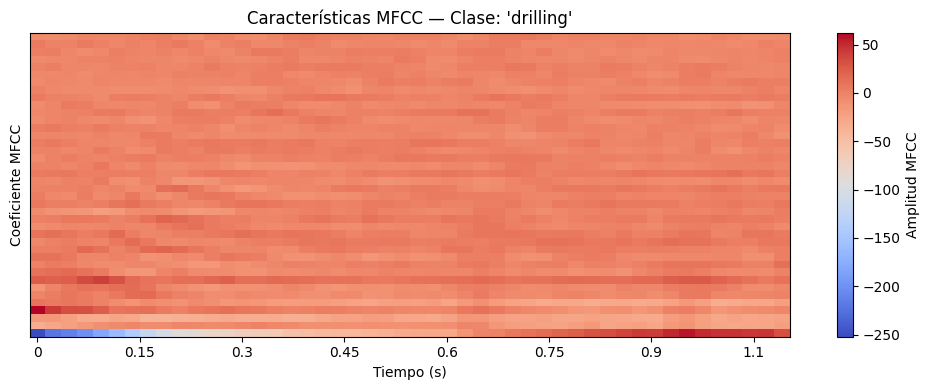

In [ ]:
# ============================================================
# 4.1.B — BASELINE DE AUDIO: MFCC + SVM
# ============================================================
import librosa
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import os

# Parámetros (los mismos que usaron en el punto 3)
SR         = 22050
DURACION   = 4.0
N_MFCC     = 40       # Número de coeficientes MFCC a extraer
MAX_CLIPS  = 200      # Límite para que sea rápido

# ── PASO 1: Cargar metadata y seleccionar clips ──────────────
metadata = pd.read_csv("UrbanSound8K/metadata/UrbanSound8K.csv")

# Usamos fold1-fold8 para train, fold9 para val (estándar del dataset)
train_meta = metadata[metadata['fold'].isin(range(1, 9))].sample(
    n=min(MAX_CLIPS, len(metadata[metadata['fold'].isin(range(1, 9))])),
    random_state=42
)
val_meta = metadata[metadata['fold'] == 9].sample(
    n=min(80, len(metadata[metadata['fold'] == 9])),
    random_state=42
)

print(f"Clips para entrenamiento: {len(train_meta)}")
print(f"Clips para validación:    {len(val_meta)}")

# ── PASO 2: Extraer características MFCC ────────────────────
def extraer_mfcc(fila):
    ruta = f"UrbanSound8K/audio/fold{fila['fold']}/{fila['slice_file_name']}"
    try:
        audio, _ = librosa.load(ruta, sr=SR, mono=True, duration=DURACION)
        longitud = int(SR * DURACION)
        if len(audio) < longitud:
            audio = np.pad(audio, (0, longitud - len(audio)))
        else:
            audio = audio[:longitud]
        mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC)
        # Estadísticas por coeficiente: media y desviación estándar
        return np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1)])
    except:
        return None

print("\nExtrayendo MFCC del trainset...")
X_train_audio, y_train_audio = [], []
for _, fila in train_meta.iterrows():
    feat = extraer_mfcc(fila)
    if feat is not None:
        X_train_audio.append(feat)
        y_train_audio.append(fila['class'])

print(f"✓ {len(X_train_audio)} clips procesados.")

print("Extrayendo MFCC del valset...")
X_val_audio, y_val_audio = [], []
for _, fila in val_meta.iterrows():
    feat = extraer_mfcc(fila)
    if feat is not None:
        X_val_audio.append(feat)
        y_val_audio.append(fila['class'])

print(f"✓ {len(X_val_audio)} clips procesados.")

# ── PASO 3: Entrenar SVM ─────────────────────────────────────
X_train_audio = np.array(X_train_audio)
X_val_audio   = np.array(X_val_audio)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_audio)
y_val_enc   = le.transform(y_val_audio)

scaler_audio   = StandardScaler()
X_train_audio  = scaler_audio.fit_transform(X_train_audio)
X_val_audio    = scaler_audio.transform(X_val_audio)

print("\nEntrenando SVM (kernel RBF)...")
svm_audio = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_audio.fit(X_train_audio, y_train_enc)
print("✓ SVM entrenado.")

# ── PASO 4: Evaluación ───────────────────────────────────────
y_pred_audio = svm_audio.predict(X_val_audio)
acc_audio    = accuracy_score(y_val_enc, y_pred_audio)

print(f"\n{'='*52}")
print(f"  RESULTADO BASELINE — MFCC + SVM (Audio)")
print(f"{'='*52}")
print(f"  Precisión global: {acc_audio*100:.2f}%")
print(f"\n{classification_report(y_val_enc, y_pred_audio, target_names=le.classes_)}")

# ── PASO 5: Visualización de un MFCC ────────────────────────
primera_fila = val_meta.iloc[0]
ruta_ejemplo = f"UrbanSound8K/audio/fold{primera_fila['fold']}/{primera_fila['slice_file_name']}"
audio_ej, _  = librosa.load(ruta_ejemplo, sr=SR, mono=True, duration=DURACION)
mfcc_ej      = librosa.feature.mfcc(y=audio_ej, sr=SR, n_mfcc=N_MFCC)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_ej, sr=SR, x_axis='time', cmap='coolwarm')
plt.colorbar(label='Amplitud MFCC')
plt.title(f"Características MFCC — Clase: '{primera_fila['class']}'")
plt.ylabel("Coeficiente MFCC")
plt.xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

# **7. Arquitectura del Modelo Avanzado**

In [ ]:
# ============================================================
# 4.2.A — ARQUITECTURA DEL MODELO DE VIDEO: YOLOv8
# ============================================================

# Instalación de Ultralytics (librería oficial de YOLOv8)
!pip install ultralytics --quiet

from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ── Cargar arquitectura YOLOv8n (nano) ──────────────────────
# Solo cargamos la arquitectura, aún no entrenamos
model_yolo = YOLO("yolov8n.pt")

# ── Resumen de la arquitectura ───────────────────────────────
print("=" * 52)
print("  ARQUITECTURA — YOLOv8n (Video)")
print("=" * 52)
model_yolo.info(verbose=True)

# ── Parámetros del modelo ────────────────────────────────────
total_params = sum(p.numel() for p in model_yolo.model.parameters())
print(f"\n  Total de parámetros: {total_params:,}")
print(f"  Tamaño de entrada:   640 × 640 px (igual que pipeline punto 3)")
print(f"  Número de clases:    10 (adaptado a VisDrone)")
print(f"  Backbone:            CSPDarknet")
print(f"  Neck:                PANet (Path Aggregation Network)")
print(f"  Head:                Decoupled detection head")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ARQUITECTURA — YOLOv8n (Video)
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs

  Total de parámetros: 3,157,200
  Tamaño de entrada:   640 × 640 px (igual que pipeline punto 3)
  Número de clases:    10 (adaptado a VisDrone)
  Backbone:            CSPDarknet
  Neck:                PANet (Path Aggregation Network)
  Head:                Decoupled detection head


In [ ]:
# ============================================================
# 4.2.B — ARQUITECTURA DEL MODELO DE AUDIO: CNN
# ============================================================

import torch
import torch.nn as nn

class CNNAudio(nn.Module):
    """
    Red neuronal convolucional para clasificación de sonidos urbanos.
    Entrada: espectrograma Mel de shape (1, 128, 173)
             — el mismo que produce el pipeline del punto 3 —
    Salida:  probabilidades para 10 clases de UrbanSound8K
    """
    def __init__(self, num_clases=10):
        super(CNNAudio, self).__init__()

        # ── BLOQUE 1: Extracción de características locales ──
        # Detecta patrones simples: bordes y texturas espectrales
        self.bloque1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,128,173) → (32,128,173)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # → (32, 64, 86)
            nn.Dropout(0.25)
        )

        # ── BLOQUE 2: Extracción de características intermedias ──
        # Detecta patrones más complejos: combinaciones de frecuencias
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → (64, 64, 86)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # → (64, 32, 43)
            nn.Dropout(0.25)
        )

        # ── BLOQUE 3: Extracción de características globales ──
        # Detecta patrones de alto nivel: timbre, ritmo, envolvente
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# → (128, 32, 43)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # → (128, 16, 21)
            nn.Dropout(0.25)
        )

        # ── CLASIFICADOR FINAL ───────────────────────────────
        self.clasificador = nn.Sequential(
            nn.Flatten(),                                # → (128 × 16 × 21) = 43008
            nn.Linear(128 * 16 * 21, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_clases)                  # → 10 clases
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        x = self.clasificador(x)
        return x


# ── Instanciar y mostrar resumen ─────────────────────────────
modelo_audio = CNNAudio(num_clases=10)

print("=" * 52)
print("  ARQUITECTURA — CNN Audio (UrbanSound8K)")
print("=" * 52)

# Resumen capa por capa
total_params = sum(p.numel() for p in modelo_audio.parameters())
entrenables  = sum(p.numel() for p in modelo_audio.parameters() if p.requires_grad)

print(f"\n  Entrada:             (1, 128, 173) — Espectrograma Mel")
print(f"  Bloque Conv 1:       Conv2d(1→32)  + BN + ReLU + MaxPool + Dropout")
print(f"  Bloque Conv 2:       Conv2d(32→64) + BN + ReLU + MaxPool + Dropout")
print(f"  Bloque Conv 3:       Conv2d(64→128)+ BN + ReLU + MaxPool + Dropout")
print(f"  Clasificador:        Linear(43008→256) → Linear(256→10)")
print(f"  Salida:              10 clases de sonido urbano")
print(f"\n  Total parámetros:    {total_params:,}")
print(f"  Parámetros entrenables: {entrenables:,}")

# ── Verificación con tensor de prueba ────────────────────────
tensor_prueba = torch.zeros(1, 1, 128, 173)
with torch.no_grad():
    salida = modelo_audio(tensor_prueba)

print(f"\n  Shape entrada:  {list(tensor_prueba.shape)}")
print(f"  Shape salida:   {list(salida.shape)}  ← 10 probabilidades")
print(f"\n✓ Arquitectura CNN de audio definida correctamente.")

  ARQUITECTURA — CNN Audio (UrbanSound8K)

  Entrada:             (1, 128, 173) — Espectrograma Mel
  Bloque Conv 1:       Conv2d(1→32)  + BN + ReLU + MaxPool + Dropout
  Bloque Conv 2:       Conv2d(32→64) + BN + ReLU + MaxPool + Dropout
  Bloque Conv 3:       Conv2d(64→128)+ BN + ReLU + MaxPool + Dropout
  Clasificador:        Linear(43008→256) → Linear(256→10)
  Salida:              10 clases de sonido urbano

  Total parámetros:    11,105,994
  Parámetros entrenables: 11,105,994

  Shape entrada:  [1, 1, 128, 173]
  Shape salida:   [1, 10]  ← 10 probabilidades

✓ Arquitectura CNN de audio definida correctamente.


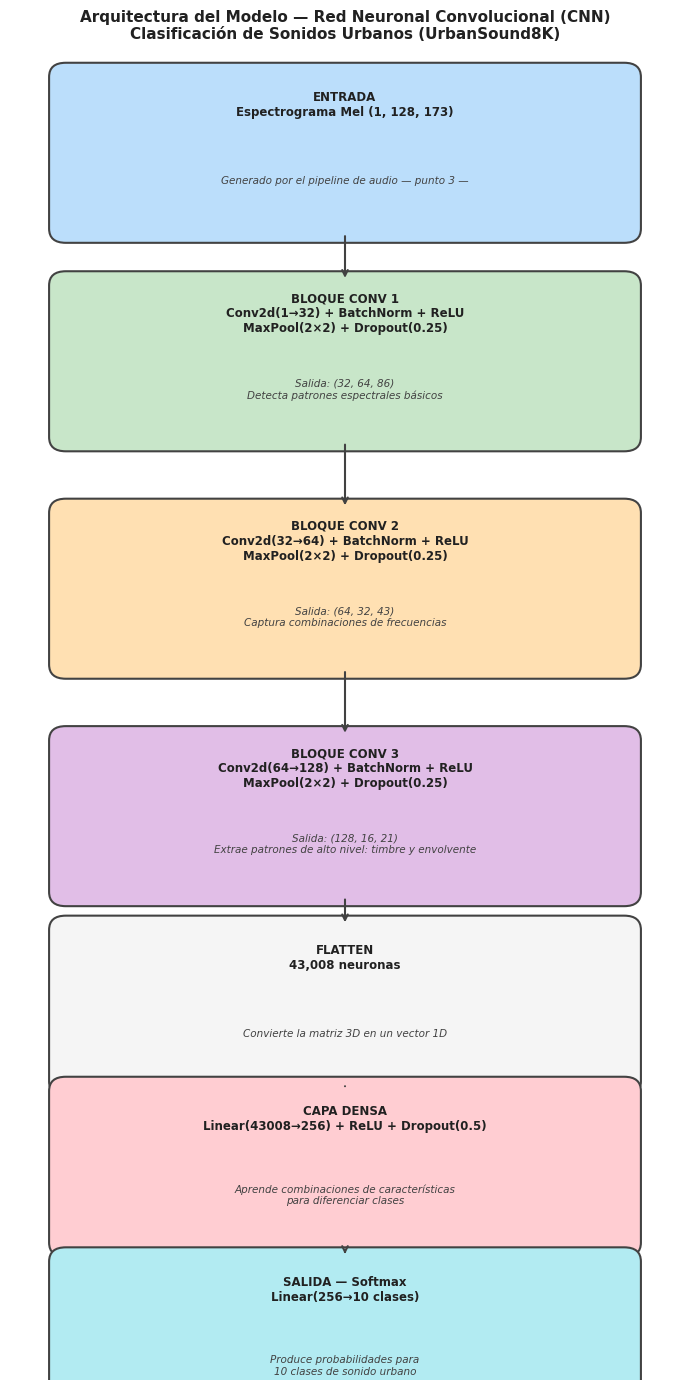

✓ Guardado: diagrama_cnn_audio.png


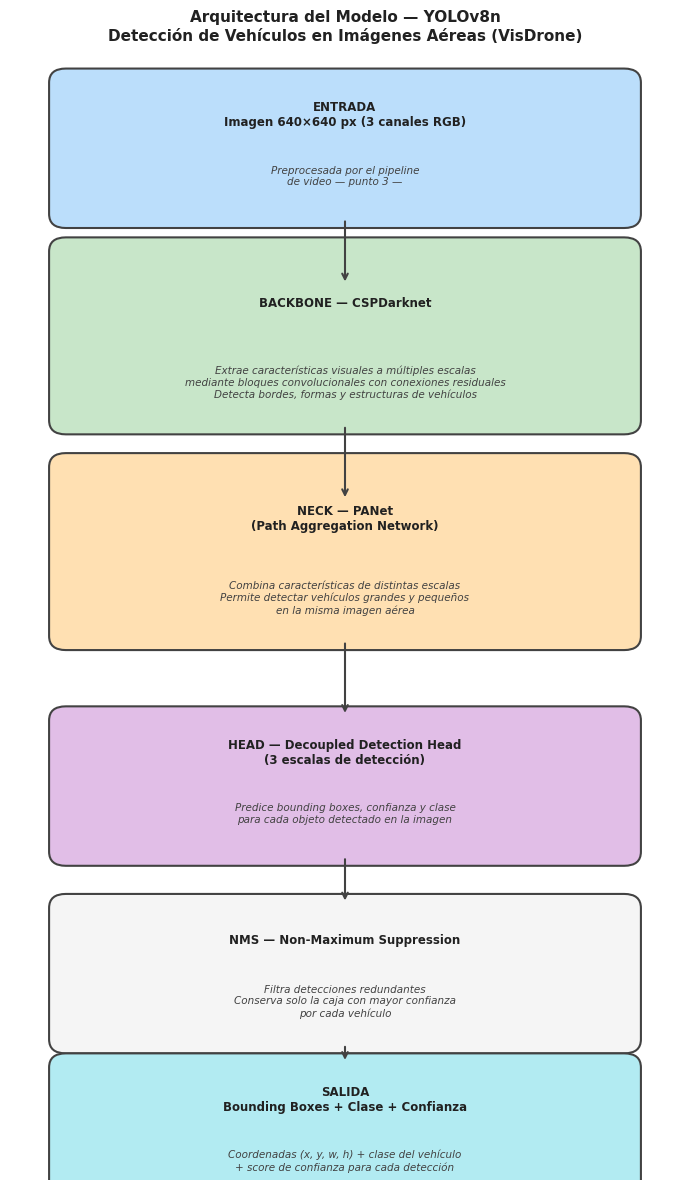

✓ Guardado: diagrama_yolov8.png


In [ ]:
# ============================================================
# 4.2.C — DIAGRAMAS ESTILO INFORME ACADÉMICO
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── DIAGRAMA CNN DE AUDIO (corregido) ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 14))
ax.set_xlim(0, 6)
ax.set_ylim(0, 14)
ax.axis('off')
fig.patch.set_facecolor('white')

capas = [
    (13.0, "ENTRADA\nEspectrograma Mel (1, 128, 173)",
           "Generado por el pipeline de audio — punto 3 —", '#BBDEFB'),
    (10.8, "BLOQUE CONV 1\nConv2d(1→32) + BatchNorm + ReLU\nMaxPool(2×2) + Dropout(0.25)",
           "Salida: (32, 64, 86)\nDetecta patrones espectrales básicos", '#C8E6C9'),
    (8.4,  "BLOQUE CONV 2\nConv2d(32→64) + BatchNorm + ReLU\nMaxPool(2×2) + Dropout(0.25)",
           "Salida: (64, 32, 43)\nCaptura combinaciones de frecuencias", '#FFE0B2'),
    (6.0,  "BLOQUE CONV 3\nConv2d(64→128) + BatchNorm + ReLU\nMaxPool(2×2) + Dropout(0.25)",
           "Salida: (128, 16, 21)\nExtrae patrones de alto nivel: timbre y envolvente", '#E1BEE7'),
    (4.0,  "FLATTEN\n43,008 neuronas",
           "Convierte la matriz 3D en un vector 1D", '#F5F5F5'),
    (2.3,  "CAPA DENSA\nLinear(43008→256) + ReLU + Dropout(0.5)",
           "Aprende combinaciones de características\npara diferenciar clases", '#FFCDD2'),
    (0.5,  "SALIDA — Softmax\nLinear(256→10 clases)",
           "Produce probabilidades para\n10 clases de sonido urbano", '#B2EBF2'),
]

yvals = [c[0] for c in capas]

for i, (y, titulo, descripcion, color) in enumerate(capas):
    rect = mpatches.FancyBboxPatch((0.5, y - 0.85), 5, 1.6,
        boxstyle="round,pad=0.15", linewidth=1.5,
        edgecolor='#424242', facecolor=color)
    ax.add_patch(rect)
    ax.text(3.0, y + 0.45, titulo, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='#212121')
    ax.text(3.0, y - 0.35, descripcion, ha='center', va='center',
            fontsize=7.5, color='#424242', style='italic')

    if i < len(capas) - 1:
        y_fin = yvals[i + 1] + 0.8
        ax.annotate("", xy=(3.0, y_fin),
                    xytext=(3.0, y - 0.9),
                    arrowprops=dict(arrowstyle="->", color='#424242', lw=1.5))

ax.set_title("Arquitectura del Modelo — Red Neuronal Convolucional (CNN)\nClasificación de Sonidos Urbanos (UrbanSound8K)",
             fontsize=11, fontweight='bold', pad=10, color='#212121')
plt.tight_layout()
plt.savefig("diagrama_cnn_audio.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Guardado: diagrama_cnn_audio.png")


# ── DIAGRAMA YOLOv8 (estilo vertical) ───────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 12))
ax2.set_xlim(0, 6)
ax2.set_ylim(0, 12)
ax2.axis('off')
fig2.patch.set_facecolor('white')

capas_yolo = [
    (11.0, "ENTRADA\nImagen 640×640 px (3 canales RGB)",
           "Preprocesada por el pipeline\nde video — punto 3 —", '#BBDEFB'),
    (8.8,  "BACKBONE — CSPDarknet",
           "Extrae características visuales a múltiples escalas\nmediante bloques convolucionales con conexiones residuales\nDetecta bordes, formas y estructuras de vehículos", '#C8E6C9'),
    (6.5,  "NECK — PANet\n(Path Aggregation Network)",
           "Combina características de distintas escalas\nPermite detectar vehículos grandes y pequeños\nen la misma imagen aérea", '#FFE0B2'),
    (4.2,  "HEAD — Decoupled Detection Head\n(3 escalas de detección)",
           "Predice bounding boxes, confianza y clase\npara cada objeto detectado en la imagen", '#E1BEE7'),
    (2.2,  "NMS — Non-Maximum Suppression",
           "Filtra detecciones redundantes\nConserva solo la caja con mayor confianza\npor cada vehículo", '#F5F5F5'),
    (0.5,  "SALIDA\nBounding Boxes + Clase + Confianza",
           "Coordenadas (x, y, w, h) + clase del vehículo\n+ score de confianza para cada detección", '#B2EBF2'),
]

for y, titulo, descripcion, color in capas_yolo:
    alto = 1.8 if y == 8.8 or y == 6.5 else 1.4
    rect = mpatches.FancyBboxPatch((0.5, y - 0.7), 5, alto,
        boxstyle="round,pad=0.15", linewidth=1.5,
        edgecolor='#424242', facecolor=color)
    ax2.add_patch(rect)
    ax2.text(3.0, y + alto/2 - 0.35, titulo, ha='center', va='center',
             fontsize=8.5, fontweight='bold', color='#212121')
    ax2.text(3.0, y - 0.3, descripcion, ha='center', va='center',
             fontsize=7.5, color='#424242', style='italic')

    if y > 0.5:
        idx = [c[0] for c in capas_yolo].index(y)
        sig_y = capas_yolo[idx + 1][0]
        ax2.annotate("", xy=(3.0, sig_y + 0.75),
                     xytext=(3.0, y - 0.75),
                     arrowprops=dict(arrowstyle="->", color='#424242', lw=1.5))

ax2.set_title("Arquitectura del Modelo — YOLOv8n\nDetección de Vehículos en Imágenes Aéreas (VisDrone)",
              fontsize=11, fontweight='bold', pad=10, color='#212121')
plt.tight_layout()
plt.savefig("diagrama_yolov8.png", dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✓ Guardado: diagrama_yolov8.png")

# **8. Proceso de Entrenamiento**

In [ ]:
# ============================================================
# 4.3.A — ENTRENAMIENTO YOLOv8n (Video — VisDrone)
# ============================================================
from ultralytics import YOLO
import os
import shutil
import glob

# ── PASO 1: Crear archivo de configuración del dataset ───────
# YOLOv8 necesita un archivo .yaml que le indique dónde están
# las imágenes y cuáles son las clases a detectar

yaml_content = """
path: /content/VisDrone2019-DET-train
train: images
val: /content/VisDrone2019-DET-val/images

nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""

with open("visdrone.yaml", "w") as f:
    f.write(yaml_content)

print("✓ Archivo visdrone.yaml creado.")

# ── PASO 2: Convertir anotaciones VisDrone a formato YOLO ────
# VisDrone usa formato: x,y,w,h,score,class
# YOLO necesita:        class cx,cy,w,h (normalizados 0-1)

def convertir_anotaciones_visdrone(carpeta_dataset):
    carpeta_anns  = os.path.join(carpeta_dataset, "annotations")
    carpeta_imgs  = os.path.join(carpeta_dataset, "images")
    carpeta_labels = os.path.join(carpeta_dataset, "labels")
    os.makedirs(carpeta_labels, exist_ok=True)

    archivos = os.listdir(carpeta_anns)
    convertidos = 0

    for archivo in archivos:
        ruta_ann = os.path.join(carpeta_anns, archivo)
        ruta_img = os.path.join(carpeta_imgs, archivo.replace(".txt", ".jpg"))
        ruta_out = os.path.join(carpeta_labels, archivo)

        import cv2
        img = cv2.imread(ruta_img)
        if img is None:
            continue
        h_img, w_img = img.shape[:2]

        lineas_yolo = []
        with open(ruta_ann, 'r') as f:
            for linea in f.readlines():
                partes = linea.strip().split(',')
                if len(partes) < 6:
                    continue
                x, y, w, h = int(partes[0]), int(partes[1]), int(partes[2]), int(partes[3])
                clase = int(partes[5])
                if clase == 0 or clase > 10 or w == 0 or h == 0:
                    continue
                clase_yolo = clase - 1
                cx = (x + w/2) / w_img
                cy = (y + h/2) / h_img
                nw = w / w_img
                nh = h / h_img
                lineas_yolo.append(f"{clase_yolo} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        with open(ruta_out, 'w') as f:
            f.write("\n".join(lineas_yolo))
        convertidos += 1

    print(f"✓ {convertidos} anotaciones convertidas en {carpeta_dataset}")

print("Convirtiendo anotaciones del trainset...")
convertir_anotaciones_visdrone("VisDrone2019-DET-train")

print("Convirtiendo anotaciones del valset...")
convertir_anotaciones_visdrone("VisDrone2019-DET-val")

# ── PASO 3: Entrenamiento ────────────────────────────────────
print("\nIniciando entrenamiento YOLOv8n...")
print("Esto puede tardar 30-60 minutos con GPU T4.\n")

model_yolo = YOLO("yolov8n.pt")

resultados = model_yolo.train(
    data    = "visdrone.yaml",
    epochs  = 35,
    imgsz   = 640,
    batch   = 16,
    name    = "yolov8_visdrone",
    project = "runs_punto4",
    device  = 0,
    patience= 10,
    verbose = True
)

# Buscar best.pt automáticamente
archivos_pt = glob.glob("/content/**/best.pt", recursive=True)
if archivos_pt:
    shutil.copy(archivos_pt[0], "/content/drive/MyDrive/datasets-perc-comp/yolov8_best.pt")
    print(f"✓ YOLOv8 best.pt guardado en Drive desde: {archivos_pt[0]}")
else:
    print("✗ No se encontró best.pt")

✓ Archivo visdrone.yaml creado.
Convirtiendo anotaciones del trainset...
✓ 6471 anotaciones convertidas en VisDrone2019-DET-train
Convirtiendo anotaciones del valset...
✓ 548 anotaciones convertidas en VisDrone2019-DET-val

Iniciando entrenamiento YOLOv8n...
Esto puede tardar 30-60 minutos con GPU T4.

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=

Preprocesando trainset...

✓ Train: 6275 clips
Preprocesando valset...

✓ Val: 816 clips
Shape X_train: torch.Size([6275, 1, 128, 173])

Iniciando entrenamiento — 50 épocas...
Época 01/50 | Loss: 2.8376 | Acc train: 21.39% | Acc val: 30.64%
Época 02/50 | Loss: 1.9464 | Acc train: 25.96% | Acc val: 36.76%
Época 03/50 | Loss: 1.9176 | Acc train: 26.47% | Acc val: 32.11%
Época 04/50 | Loss: 1.8574 | Acc train: 28.35% | Acc val: 35.42%
Época 05/50 | Loss: 1.8262 | Acc train: 28.37% | Acc val: 41.79%
Época 06/50 | Loss: 1.7944 | Acc train: 30.61% | Acc val: 41.05%
Época 07/50 | Loss: 1.7487 | Acc train: 31.78% | Acc val: 41.79%
Época 08/50 | Loss: 1.7099 | Acc train: 33.18% | Acc val: 53.19%
Época 09/50 | Loss: 1.6794 | Acc train: 35.12% | Acc val: 49.39%
Época 10/50 | Loss: 1.6716 | Acc train: 34.42% | Acc val: 56.25%
Época 11/50 | Loss: 1.5115 | Acc train: 40.54% | Acc val: 60.66%
Época 12/50 | Loss: 1.4740 | Acc train: 41.12% | Acc val: 64.09%
Época 13/50 | Loss: 1.4543 | Acc train: 42.2

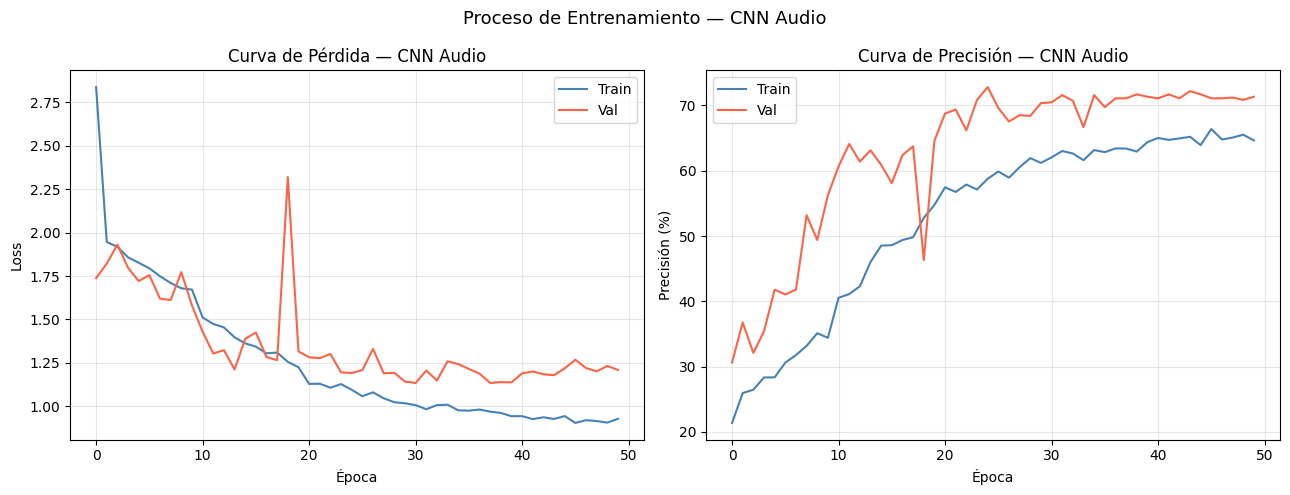


  RESULTADO FINAL — CNN Audio
  Precisión en validación: 71.32%
  Modelo guardado en:      cnn_audio_urbansound.pt
✓ CNN Audio guardada en Drive.


In [ ]:
# ============================================================
# 4.3.B — ENTRENAMIENTO CNN AUDIO (versión optimizada)
# Preprocesa todos los espectrogramas primero, luego entrena
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import librosa
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

SR       = 22050
DURACION = 4.0
N_MELS   = 128
HOP_LENGTH = 512
N_FFT    = 2048

def preprocesar_clip_rapido(ruta):
    try:
        audio, _ = librosa.load(ruta, sr=SR, mono=True, duration=DURACION)
        longitud = int(SR * DURACION)
        if len(audio) < longitud:
            audio = np.pad(audio, (0, longitud - len(audio)))
        else:
            audio = audio[:longitud]
        mel = librosa.feature.melspectrogram(
            y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
        return mel_db.astype(np.float32)
    except:
        return np.zeros((128, 173), dtype=np.float32)

# ── PASO 1: Preprocesar todo el dataset de una vez ───────────
metadata = pd.read_csv("UrbanSound8K/metadata/UrbanSound8K.csv")
le = LabelEncoder()
le.fit(metadata['class'])

def cargar_split(folds, max_por_clase=150):
    X, y = [], []
    subset = metadata[metadata['fold'].isin(folds)]
    # Limitar por clase para balancear y acelerar
    subset = subset.groupby('class').head(max_por_clase).reset_index(drop=True)
    total = len(subset)
    for i, (_, fila) in enumerate(subset.iterrows()):
        if i % 100 == 0:
            print(f"  Procesando {i}/{total}...", end='\r')
        ruta = f"UrbanSound8K/audio/fold{fila['fold']}/{fila['slice_file_name']}"
        X.append(preprocesar_clip_rapido(ruta))
        y.append(le.transform([fila['class']])[0])
    return np.array(X), np.array(y)

print("Preprocesando trainset...")
X_train, y_train = cargar_split(range(1, 9), max_por_clase=700)
print(f"\n✓ Train: {len(X_train)} clips")

print("Preprocesando valset...")
X_val, y_val = cargar_split([9], max_por_clase=100)
print(f"\n✓ Val: {len(X_val)} clips")

# ── PASO 2: Crear dataloaders desde tensores (ultrarrápido) ──
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
X_val_t   = torch.FloatTensor(X_val).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_val_t   = torch.LongTensor(y_val)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                          batch_size=32, shuffle=False)

print(f"Shape X_train: {X_train_t.shape}")

# ── PASO 3: Entrenamiento ─────────────────────────────────────
device      = torch.device("cuda")
modelo      = CNNAudio(num_clases=10).to(device)
criterio    = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)
scheduler   = optim.lr_scheduler.StepLR(optimizador, step_size=10, gamma=0.5)

EPOCAS    = 50
historial = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\nIniciando entrenamiento — {EPOCAS} épocas...")

for epoca in range(EPOCAS):
    modelo.train()
    loss_train, correctos_train, total_train = 0, 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizador.zero_grad()
        salida = modelo(X)
        loss   = criterio(salida, y)
        loss.backward()
        optimizador.step()
        loss_train      += loss.item()
        correctos_train += (salida.argmax(1) == y).sum().item()
        total_train     += y.size(0)

    modelo.eval()
    loss_val, correctos_val, total_val = 0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            salida = modelo(X)
            loss   = criterio(salida, y)
            loss_val      += loss.item()
            correctos_val += (salida.argmax(1) == y).sum().item()
            total_val     += y.size(0)

    scheduler.step()
    acc_train = correctos_train / total_train * 100
    acc_val   = correctos_val   / total_val   * 100
    historial['train_loss'].append(loss_train / len(train_loader))
    historial['val_loss'].append(loss_val     / len(val_loader))
    historial['train_acc'].append(acc_train)
    historial['val_acc'].append(acc_val)

    print(f"Época {epoca+1:02d}/{EPOCAS} | "
          f"Loss: {loss_train/len(train_loader):.4f} | "
          f"Acc train: {acc_train:.2f}% | "
          f"Acc val: {acc_val:.2f}%")

# ── PASO 4: Gráficas ─────────────────────────────────────────
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
ejes[0].plot(historial['train_loss'], label='Train', color='steelblue')
ejes[0].plot(historial['val_loss'],   label='Val',   color='tomato')
ejes[0].set_title("Curva de Pérdida — CNN Audio")
ejes[0].set_xlabel("Época")
ejes[0].set_ylabel("Loss")
ejes[0].legend()
ejes[0].grid(True, alpha=0.3)

ejes[1].plot(historial['train_acc'], label='Train', color='steelblue')
ejes[1].plot(historial['val_acc'],   label='Val',   color='tomato')
ejes[1].set_title("Curva de Precisión — CNN Audio")
ejes[1].set_xlabel("Época")
ejes[1].set_ylabel("Precisión (%)")
ejes[1].legend()
ejes[1].grid(True, alpha=0.3)

plt.suptitle("Proceso de Entrenamiento — CNN Audio", fontsize=13)
plt.tight_layout()
plt.savefig("curvas_entrenamiento_cnn.png", dpi=150, bbox_inches='tight')
plt.show()

# ── PASO 5: Guardar modelo ───────────────────────────────────
torch.save(modelo.state_dict(), "cnn_audio_urbansound.pt")
acc_final = historial['val_acc'][-1]
print(f"\n{'='*52}")
print(f"  RESULTADO FINAL — CNN Audio")
print(f"{'='*52}")
print(f"  Precisión en validación: {acc_final:.2f}%")
print(f"  Modelo guardado en:      cnn_audio_urbansound.pt")

# ── PASO 6: Guardar CNN en Drive ─────────────────────────────
import shutil
shutil.copy(
    "/content/cnn_audio_urbansound.pt",
    "/content/drive/MyDrive/datasets-perc-comp/cnn_audio_urbansound.pt"
)
print("✓ CNN Audio guardada en Drive.")

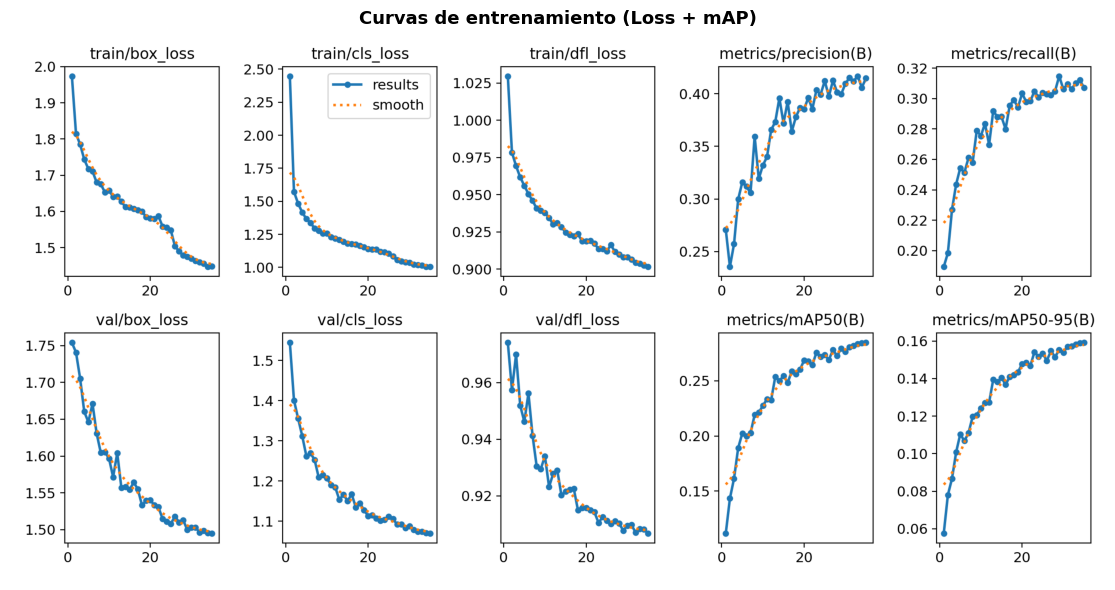

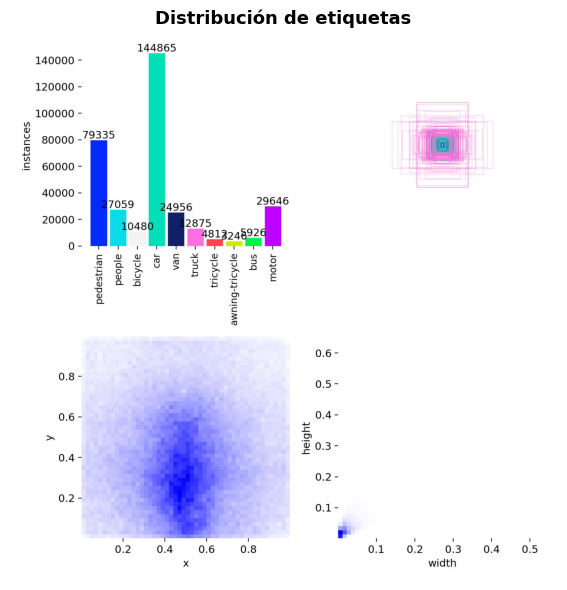

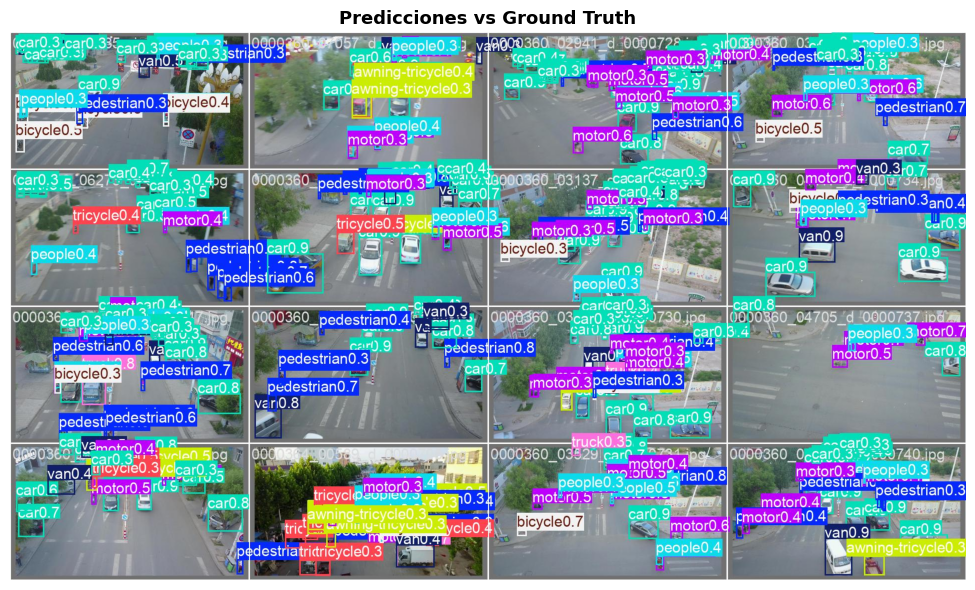

In [ ]:
# ============================================================
# GRÁFICAS DE ENTRENAMIENTO — YOLOv8
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

ruta_resultados = "/content/runs/detect/runs_punto4/yolov8_visdrone"

# Imágenes que genera YOLOv8 automáticamente
graficas = {
    "Curvas de entrenamiento (Loss + mAP)": "results.png",
    "Distribución de etiquetas":            "labels.jpg",
    "Predicciones vs Ground Truth":         "val_batch0_pred.jpg",
}

for titulo, archivo in graficas.items():
    ruta = os.path.join(ruta_resultados, archivo)
    if os.path.exists(ruta):
        img = mpimg.imread(ruta)
        plt.figure(figsize=(14, 6))
        plt.imshow(img)
        plt.title(titulo, fontsize=13, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"✗ No encontrado: {archivo}")

 EVALUACIÓN CUANTITATIVA - CNN AUDIO
                  precision    recall  f1-score   support

 air_conditioner       0.53      0.16      0.25       100
        car_horn       0.96      0.84      0.90        32
children_playing       0.80      0.73      0.76       100
        dog_bark       0.57      0.75      0.65       100
        drilling       0.63      0.61      0.62       100
   engine_idling       0.88      0.91      0.90        89
        gun_shot       0.93      0.84      0.88        31
      jackhammer       0.55      0.90      0.69        82
           siren       0.79      0.71      0.75        82
    street_music       0.81      0.91      0.86       100

        accuracy                           0.71       816
       macro avg       0.75      0.74      0.72       816
    weighted avg       0.71      0.71      0.69       816



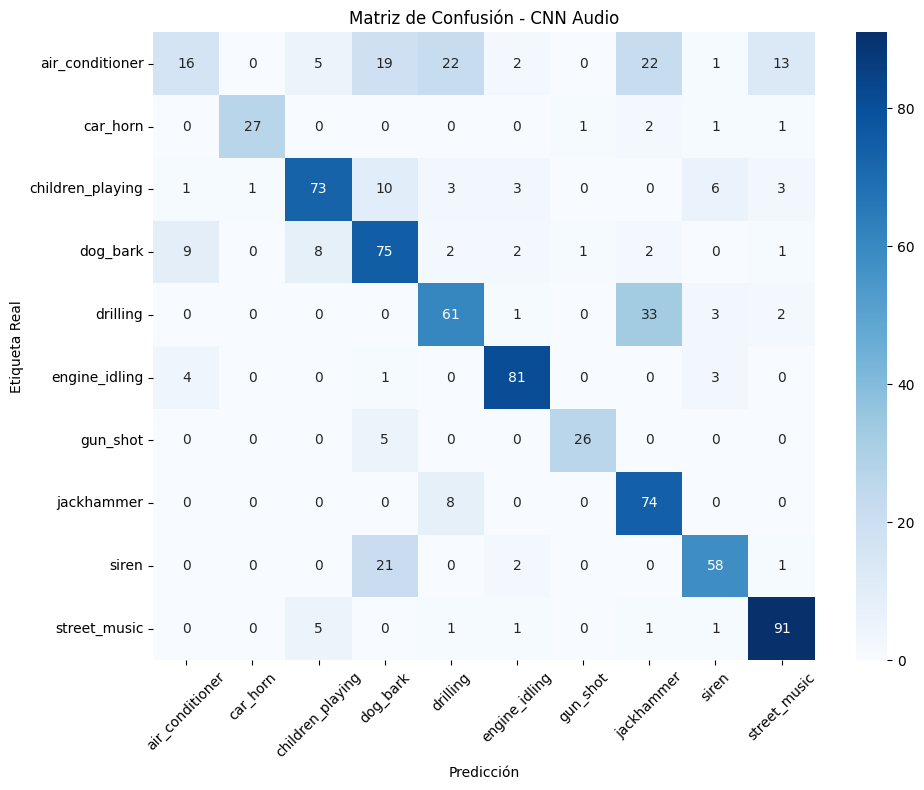


 EVALUACIÓN CUALITATIVA - CNN AUDIO


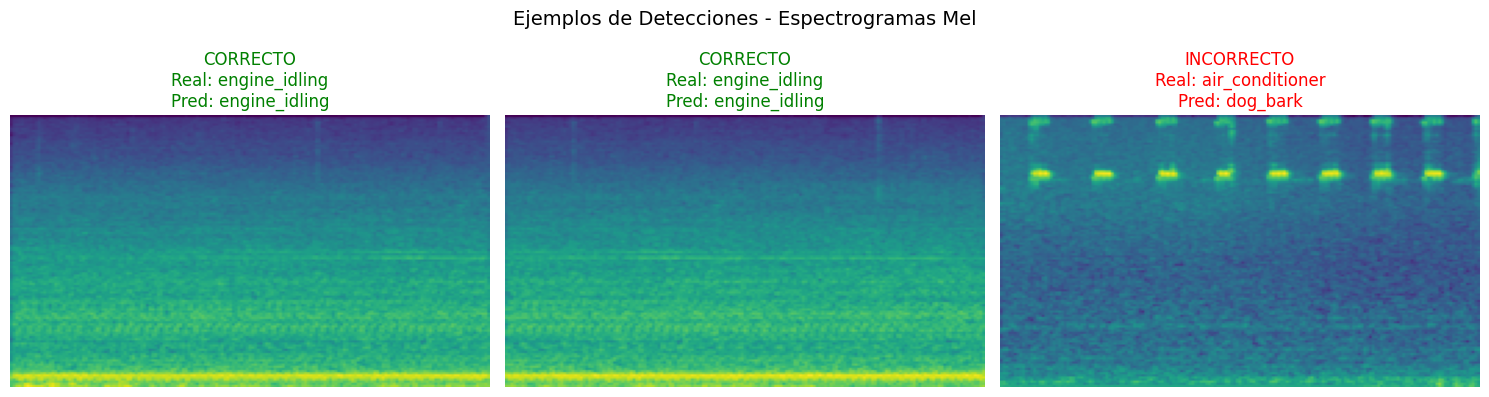

In [ ]:
# ============================================================
# 5. RESULTADOS DEL MODELO - AUDIO (CNN)
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("="*52)
print(" EVALUACIÓN CUANTITATIVA - CNN AUDIO")
print("="*52)

# 1. Obtener predicciones del conjunto de validación
modelo.eval()
y_true_audio = []
y_pred_audio = []
espectrogramas_val = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        salida = modelo(X_batch)
        preds = salida.argmax(dim=1)

        y_true_audio.extend(y_batch.cpu().numpy())
        y_pred_audio.extend(preds.cpu().numpy())
        espectrogramas_val.extend(X_batch.cpu().numpy())

y_true_audio = np.array(y_true_audio)
y_pred_audio = np.array(y_pred_audio)

# 2. Reporte de Clasificación (Precisión, Recall, F1)
nombres_clases_audio = le.classes_
reporte_audio = classification_report(y_true_audio, y_pred_audio, target_names=nombres_clases_audio)
print(reporte_audio)

# 3. Matriz de Confusión
cm_audio = confusion_matrix(y_true_audio, y_pred_audio)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_audio, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases_audio, yticklabels=nombres_clases_audio)
plt.title('Matriz de Confusión - CNN Audio')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("matriz_confusion_audio.png", dpi=150)
plt.show()

# 4. Evaluación Cualitativa (Ejemplos correctos e incorrectos)
print("\n" + "="*52)
print(" EVALUACIÓN CUALITATIVA - CNN AUDIO")
print("="*52)

indices_correctos = np.where(y_true_audio == y_pred_audio)[0]
indices_incorrectos = np.where(y_true_audio != y_pred_audio)[0]

fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

# Mostrar 2 correctos
for i in range(2):
    idx = indices_correctos[i]
    ejes[i].imshow(espectrogramas_val[idx][0], origin='lower', aspect='auto', cmap='viridis')
    ejes[i].set_title(f"CORRECTO\nReal: {nombres_clases_audio[y_true_audio[idx]]}\nPred: {nombres_clases_audio[y_pred_audio[idx]]}", color='green')
    ejes[i].axis('off')

# Mostrar 1 incorrecto
idx_err = indices_incorrectos[0]
ejes[2].imshow(espectrogramas_val[idx_err][0], origin='lower', aspect='auto', cmap='viridis')
ejes[2].set_title(f"INCORRECTO\nReal: {nombres_clases_audio[y_true_audio[idx_err]]}\nPred: {nombres_clases_audio[y_pred_audio[idx_err]]}", color='red')
ejes[2].axis('off')

plt.suptitle("Ejemplos de Detecciones - Espectrogramas Mel", fontsize=14)
plt.tight_layout()
plt.savefig("detecciones_cualitativas_audio.png", dpi=150)
plt.show()

 MÉTRICAS DE RENDIMIENTO - YOLOv8 (Video)
Métricas en la última época:
Precisión (P):  0.4148
Recall (R):     0.3072
mAP50:          0.2848
mAP50-95:       0.1592


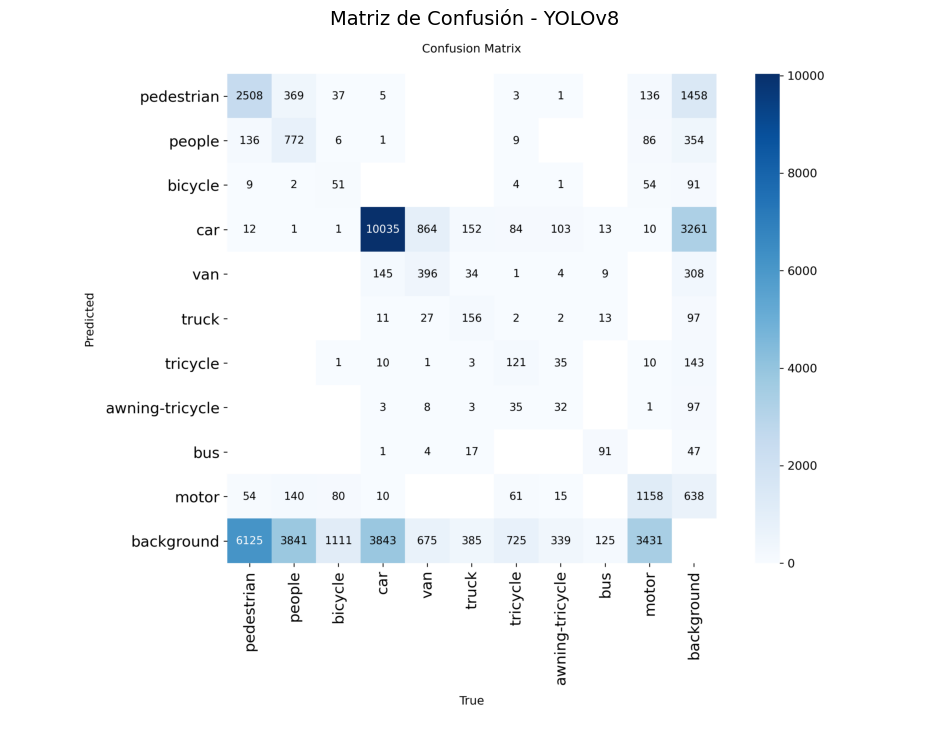

In [ ]:
# ============================================================
# 5. RESULTADOS DEL MODELO - VIDEO (YOLOv8)
# ============================================================
import pandas as pd
import matplotlib.image as mpimg
import os

ruta_yolo = "/content/runs/detect/runs_punto4/yolov8_visdrone"

print("="*52)
print(" MÉTRICAS DE RENDIMIENTO - YOLOv8 (Video)")
print("="*52)
# YOLO guarda las métricas en un archivo results.csv
if os.path.exists(f"{ruta_yolo}/results.csv"):
    df_results = pd.read_csv(f"{ruta_yolo}/results.csv")
    df_results.columns = df_results.columns.str.strip()
    ultima_epoca = df_results.iloc[-1]

    print(f"Métricas en la última época:")
    print(f"Precisión (P):  {ultima_epoca['metrics/precision(B)']:.4f}")
    print(f"Recall (R):     {ultima_epoca['metrics/recall(B)']:.4f}")
    print(f"mAP50:          {ultima_epoca['metrics/mAP50(B)']:.4f}")
    print(f"mAP50-95:       {ultima_epoca['metrics/mAP50-95(B)']:.4f}")

# Mostrar Matriz de Confusión generada por YOLO
ruta_cm = f"{ruta_yolo}/confusion_matrix.png"
if os.path.exists(ruta_cm):
    plt.figure(figsize=(12, 10))
    img_cm = mpimg.imread(ruta_cm)
    plt.imshow(img_cm)
    plt.axis('off')
    plt.title("Matriz de Confusión - YOLOv8", fontsize=14)
    plt.show()